# How much does uniformity cost?

Section 5.6 of the paper asks: against a certificate that only has to be valid at *one*
pre-chosen $k$, how much wider is a band that has to be valid at *every* $k$ simultaneously?
This notebook builds that comparison directly.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from src.bands import sorted_filtration, uniform_band
from src.baselines import clopper_pearson, hoeffding, empirical_bernstein

rng = np.random.default_rng(20260727)

## One calibration set, every certificate applied to it

We'll build one realistic-looking risk-coverage curve, then ask what each certificate says
at a single fixed point $k_0$ -- versus what Theorem 1's band says there, when it also has
to hold at every other $k$ at the same time.

In [2]:
n = 10_000
delta = 0.05
eta = rng.beta(2, 5, size=n)  # a spread of base rates
scores = -eta + rng.normal(scale=0.3, size=n)  # an informative-but-noisy score
losses = rng.binomial(1, eta).astype(float)

pi = sorted_filtration.build_permutation(scores, rng)
curves = sorted_filtration.realized_and_empirical_curves(losses, pi, eta=eta)
U_k_uniform = uniform_band._band_from_curve(curves.Rhat_k, delta=delta)

k0 = 5000  # a single, pre-registered fixed point
S_k0 = int(round(k0 * curves.Rhat_k[k0 - 1]))

cp_bound = clopper_pearson.upper_bound(S_k0, k0, delta)
hoeff_bound = hoeffding.upper_bound(curves.Rhat_k[k0 - 1], k0, delta)
eb_bound = empirical_bernstein.upper_bound(losses[pi[:k0]], delta)
uniform_bound_at_k0 = U_k_uniform[k0 - 1]

print(f"At k0={k0}, Rhat_k0={curves.Rhat_k[k0-1]:.4f}:")
print(f"  Clopper-Pearson (fixed k0 only):      {cp_bound:.4f}  (width {cp_bound - curves.Rhat_k[k0-1]:.4f})")
print(f"  Hoeffding (fixed k0 only):             {hoeff_bound:.4f}  (width {hoeff_bound - curves.Rhat_k[k0-1]:.4f})")
print(f"  Empirical Bernstein (fixed k0 only):   {eb_bound:.4f}  (width {eb_bound - curves.Rhat_k[k0-1]:.4f})")
print(f"  Theorem 1 (valid at EVERY k):          {uniform_bound_at_k0:.4f}  (width {uniform_bound_at_k0 - curves.Rhat_k[k0-1]:.4f})")

At k0=5000, Rhat_k0=0.2258:
  Clopper-Pearson (fixed k0 only):      0.2357  (width 0.0099)
  Hoeffding (fixed k0 only):             0.2431  (width 0.0173)
  Empirical Bernstein (fixed k0 only):   0.2436  (width 0.0178)
  Theorem 1 (valid at EVERY k):          0.2558  (width 0.0300)


The uniform band is visibly wider -- that's the price Theorem 2 says is unavoidable. But
the fixed-$k_0$ certificates only earned that narrower width by promising something weaker:
validity at $k_0$ *alone*. The moment someone looks at the curve and picks a *different* $k$
based on what looks good, that promise is void. Let's see this happen directly.

In [3]:
# What if, instead of the pre-registered k0, an analyst picks whichever k looks best?
# (restricted to k >= k_min=100, matching the paper's own convention -- an analyst
# realistically screens candidate operating points from some reasonable sample size
# onward, not literally k=1, which is a degenerate single-item edge case)
k_min = 100
k_selected = int(np.argmin(curves.Rhat_k[k_min - 1:])) + k_min
print(f"Pre-registered k0={k0} vs. post-hoc-selected k={k_selected}")
print(f"Rhat_k at the selected point: {curves.Rhat_k[k_selected-1]:.4f} (looks great!)")

# Apply the SAME fixed-k0-style Clopper-Pearson formula, just plugged in at the new k
S_selected = int(round(k_selected * curves.Rhat_k[k_selected - 1]))
cp_at_selected = clopper_pearson.upper_bound(S_selected, k_selected, delta)
uniform_at_selected = U_k_uniform[k_selected - 1]

print(f"\nClopper-Pearson 'certificate' at the selected k: {cp_at_selected:.4f}")
print(f"Theorem 1's band at the same k (still valid, since it was built for every k): {uniform_at_selected:.4f}")
print(f"\nRealized risk (ground truth) at this k: {curves.Rbar_k[k_selected-1]:.4f}")

Pre-registered k0=5000 vs. post-hoc-selected k=271
Rhat_k at the selected point: 0.1255 (looks great!)

Clopper-Pearson 'certificate' at the selected k: 0.1635
Theorem 1's band at the same k (still valid, since it was built for every k): 0.2552

Realized risk (ground truth) at this k: 0.1546


Clopper-Pearson's formula doesn't know or care that $k$ was chosen *because* it looked
good -- it just reports a number, computed as if $k$ had been fixed in advance. Whether that
number is trustworthy after selection is exactly the question Theorem 1 is built to answer
correctly, and the fixed-$k_0$ baselines are not.

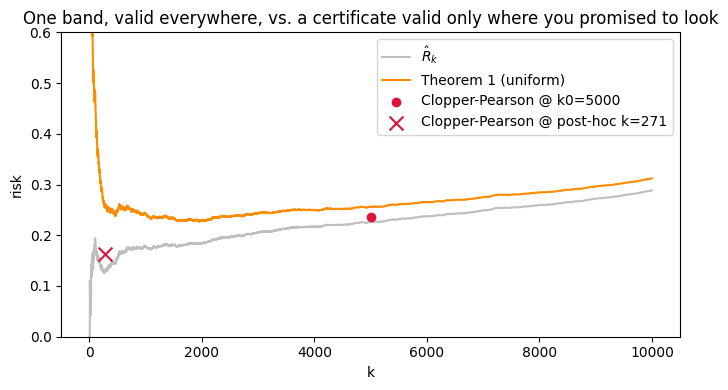

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
k_axis = np.arange(1, n + 1)
ax.plot(k_axis, curves.Rhat_k, color="gray", alpha=0.5, label=r"$\hat R_k$")
ax.plot(k_axis, U_k_uniform, color="darkorange", label="Theorem 1 (uniform)")
ax.scatter([k0], [cp_bound], color="crimson", zorder=5, label=f"Clopper-Pearson @ k0={k0}")
ax.scatter([k_selected], [cp_at_selected], color="crimson", marker="x", s=100, zorder=5,
           label=f"Clopper-Pearson @ post-hoc k={k_selected}")
ax.set_xlabel("k")
ax.set_ylabel("risk")
ax.set_ylim(0, 0.6)
ax.legend()
ax.set_title("One band, valid everywhere, vs. a certificate valid only where you promised to look")
plt.tight_layout()
plt.show()

## Where to go next

- `03_wsr_bug_deepdive.ipynb` -- one of the baselines above (the betting bound, not shown
  here) has a real implementation defect the paper's own audit found; see that notebook for
  the mechanism.
- `04_block_robustness_demo.ipynb` -- what happens to Theorem 1's own guarantee when items
  aren't independent, and how Theorem 4 fixes it.
- `docs/REPRODUCING.md` -- the full deployment protocol this comparison is a miniature of.